The following command forsec the kernel to use cpu

In [20]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""


Checking if fastembed works:

In [21]:
from fastembed import TextEmbedding


In [22]:
documents = [
    "This is built to be faster and lighter...",
    "fastembed is supported by and maintained by Qdrant.",
]


In [ ]:
embedding_model = TextEmbedding(model_name="BAAI/bge-large-en-v1.5")


print("The model BAAI/bge-small-en-v1.5 is ready to use.")

embeddings_generator = embedding_model.embed(documents)  # reminder this is a generator
embeddings_list = list(embedding_model.embed(documents))
  # you can also convert the generator to a list, and that to a numpy array
len(embeddings_list[0]) # Vector of 384 dimensions

In [26]:
embeddings_list

[array([-0.03194274,  0.0117594 , -0.04059421, ...,  0.00539083,
         0.01946498,  0.01179603], shape=(1024,), dtype=float32),
 array([-0.01740589,  0.01230743, -0.04100205, ..., -0.01522549,
        -0.00651987,  0.00830514], shape=(1024,), dtype=float32)]

In [27]:
import numpy as np

In [28]:
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))


In [29]:
cosine_similarity(embeddings_list[0], embeddings_list[1])

np.float32(0.52591705)

    Running compare models code using fastembed on cpu
    It supports following models from the list of models we previously considered: 
    1. sentence-transformers/all-MiniLM-L6-v2
    2. nomic-ai/nomic-embed-text-v1.5-Q
    3. intfloat/multilingual-e5-large
    4. mixedbread-ai/mxbai-embed-large-v1
    
    


 Running for model: sentence-transformers/all-MiniLM-L6-v2


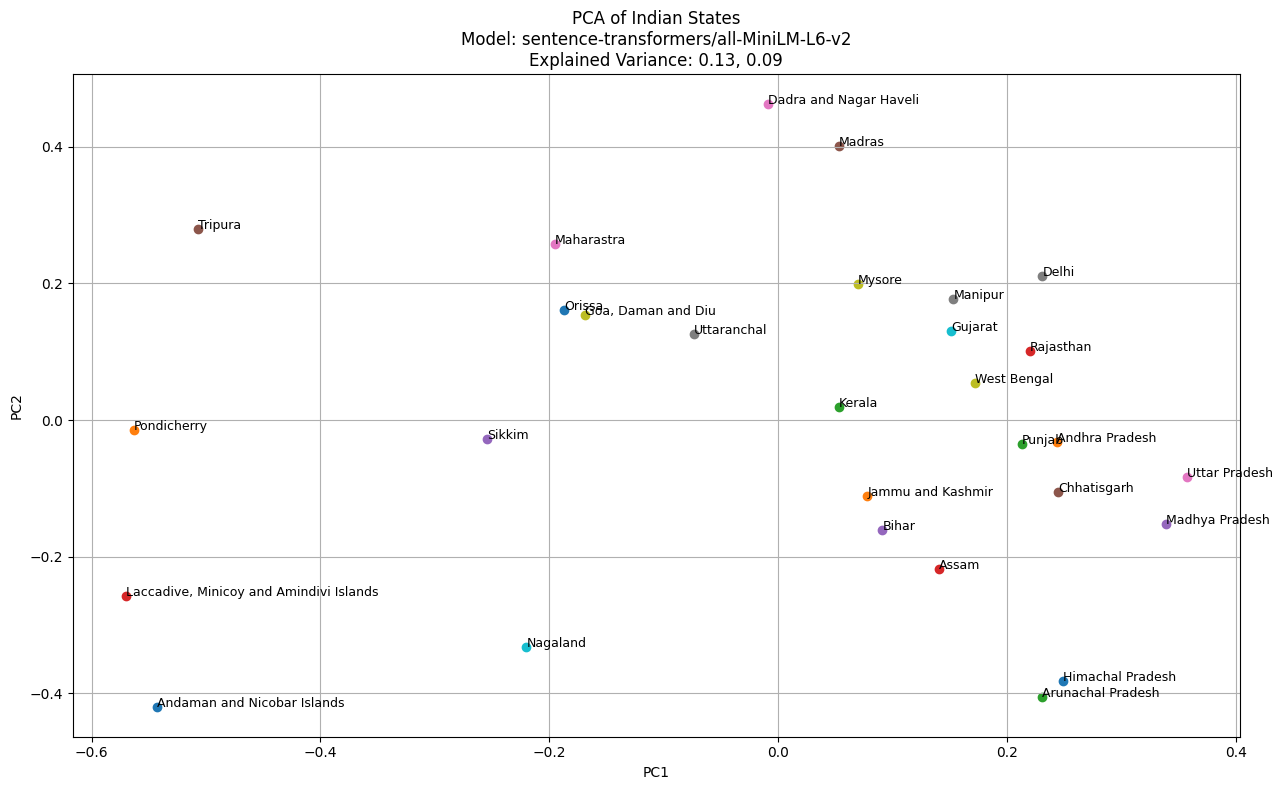


 Running for model: nomic-ai/nomic-embed-text-v1.5-Q


/tmp/ipykernel_867886/2313993004.py:20: UserWarning: The model 'nomic-ai/nomic-embed-text-v1.5-Q' has been updated on HuggingFace. Please review the latest documentation on HF and release notes to ensure compatibility with your workflow. 
  embedding_model = TextEmbedding(model_name=model_name)


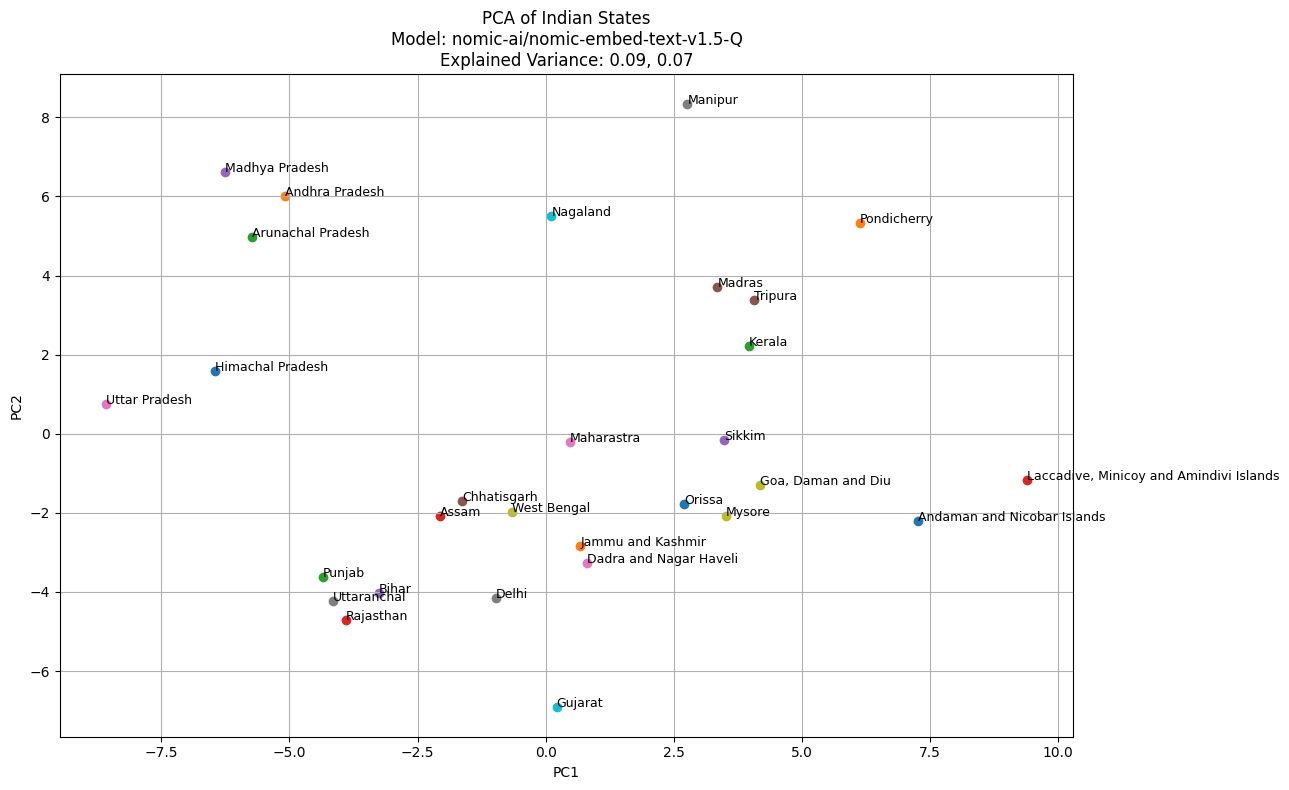


 Running for model: intfloat/multilingual-e5-large


/tmp/ipykernel_867886/2313993004.py:20: UserWarning: The model intfloat/multilingual-e5-large now uses mean pooling instead of CLS embedding. In order to preserve the previous behaviour, consider either pinning fastembed version to 0.5.1 or using `add_custom_model` functionality.
  embedding_model = TextEmbedding(model_name=model_name)


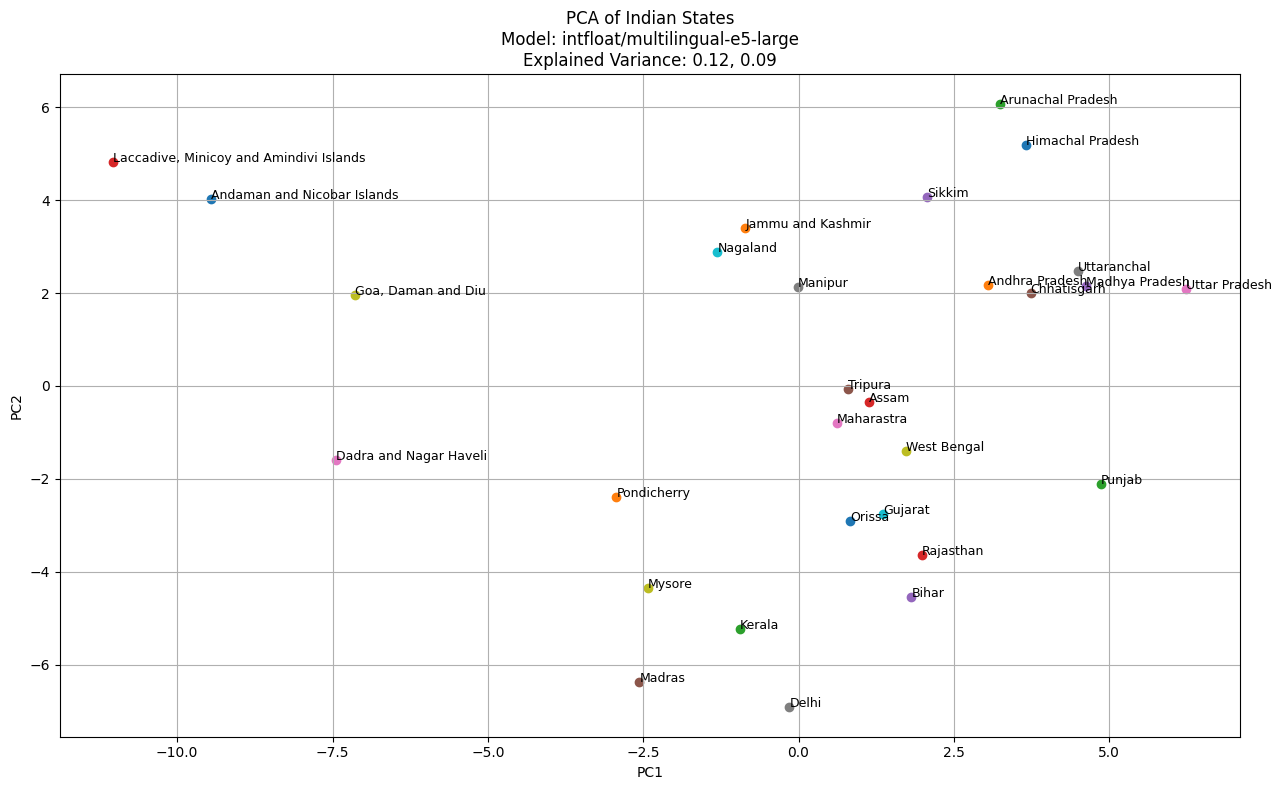


 Running for model: mixedbread-ai/mxbai-embed-large-v1


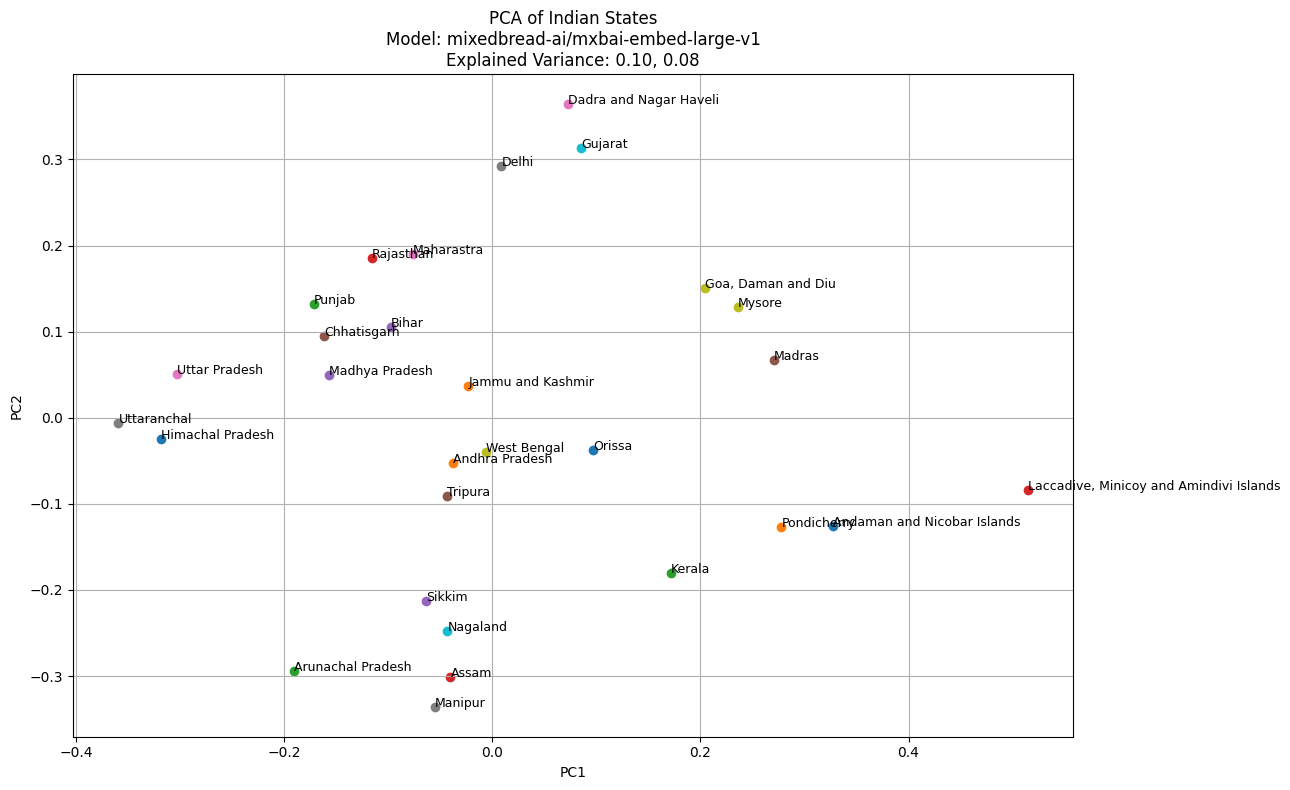

In [30]:

from fastembed import TextEmbedding

# Load data
df = pd.read_csv("../data/India_district_mappings.csv")
state_names = df["State"].dropna().unique().tolist()

# List of models to test 
models = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "nomic-ai/nomic-embed-text-v1.5-Q",
    "intfloat/multilingual-e5-large",
    "mixedbread-ai/mxbai-embed-large-v1"
]


for model_name in models:
    print(f"\n Running for model: {model_name}")
    
    # Load embedding model
    embedding_model = TextEmbedding(model_name=model_name)
    
    # Generate embeddings
    embeddings = list(embedding_model.embed(state_names))
    embeddings_array = np.array(embeddings)

    # PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embeddings_array)
    explained_var = pca.explained_variance_ratio_

    # Plot
    plt.figure(figsize=(13, 8))
    for i, label in enumerate(state_names):
        x, y = pca_result[i]
        plt.scatter(x, y)
        plt.text(x, y, label, fontsize=9)

    plt.title(f"PCA of Indian States\nModel: {model_name}\nExplained Variance: {explained_var[0]:.2f}, {explained_var[1]:.2f}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Silhoutte SCORE


 Evaluating sentence-transformers/all-MiniLM-L6-v2


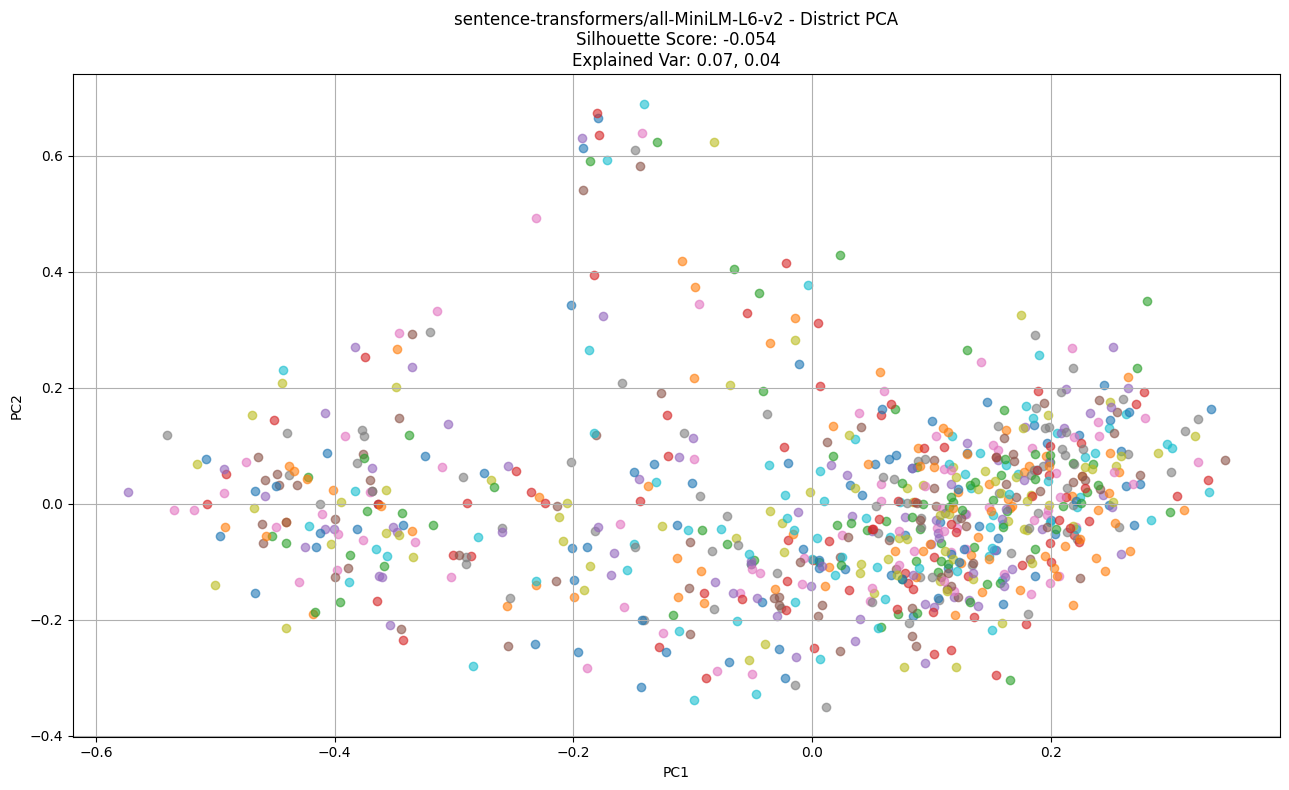


 Evaluating nomic-ai/nomic-embed-text-v1.5-Q


/tmp/ipykernel_867886/3490465801.py:25: UserWarning: The model 'nomic-ai/nomic-embed-text-v1.5-Q' has been updated on HuggingFace. Please review the latest documentation on HF and release notes to ensure compatibility with your workflow. 
  model = TextEmbedding(model_name=model_name)


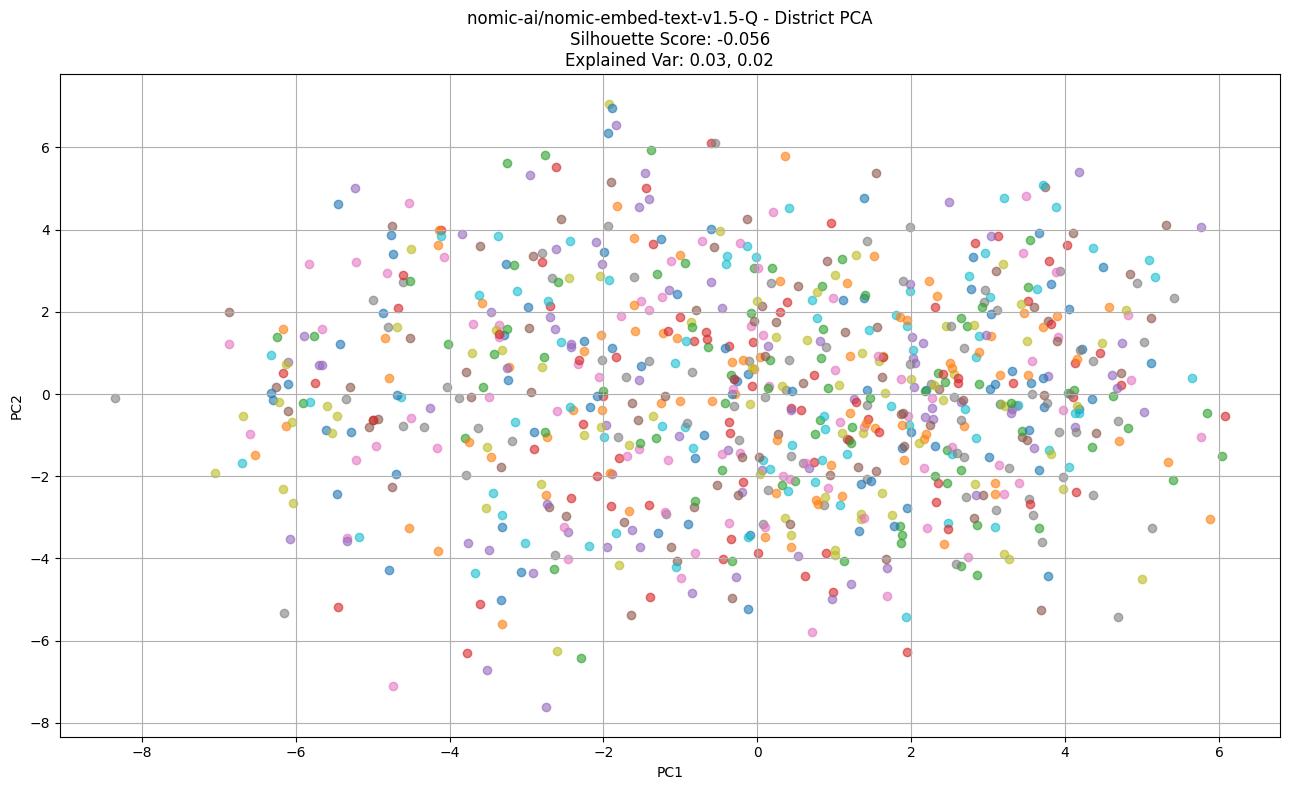


 Evaluating intfloat/multilingual-e5-large


/tmp/ipykernel_867886/3490465801.py:25: UserWarning: The model intfloat/multilingual-e5-large now uses mean pooling instead of CLS embedding. In order to preserve the previous behaviour, consider either pinning fastembed version to 0.5.1 or using `add_custom_model` functionality.
  model = TextEmbedding(model_name=model_name)


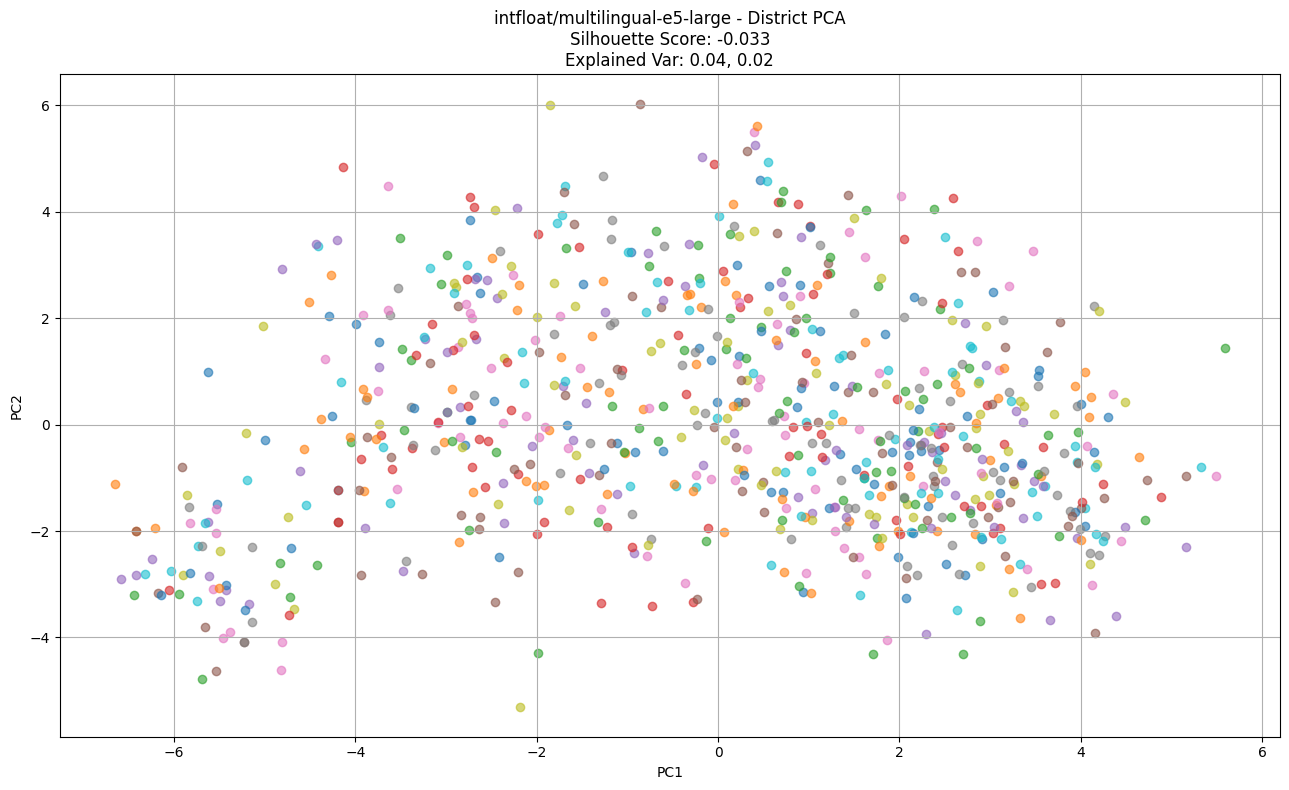


 Evaluating mixedbread-ai/mxbai-embed-large-v1


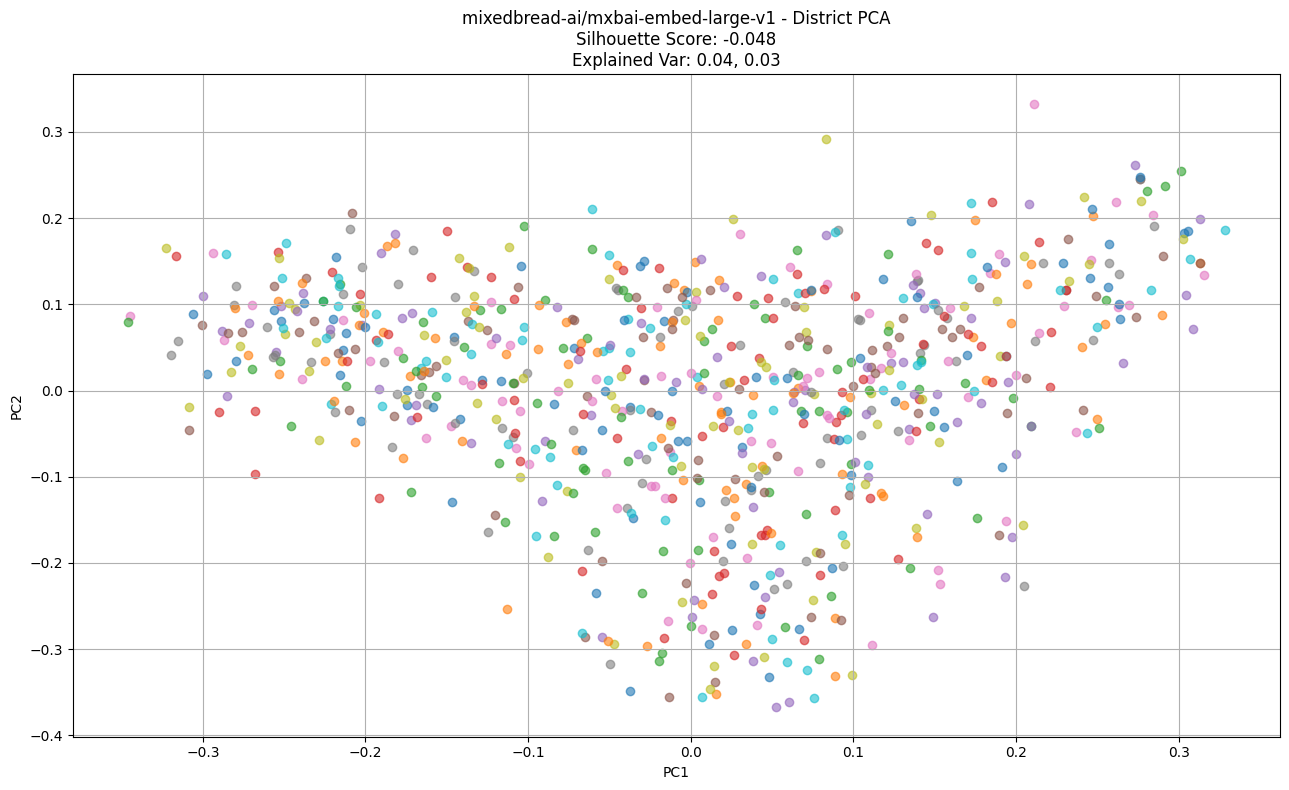


 Silhouette Scores:
sentence-transformers/all-MiniLM-L6-v2: -0.054
nomic-ai/nomic-embed-text-v1.5-Q: -0.056
intfloat/multilingual-e5-large: -0.033
mixedbread-ai/mxbai-embed-large-v1: -0.048


In [31]:
# Load district-level data
india_districts = pd.read_csv("../data/India_all_state_districts.csv")

# Label and cluster
labels = india_districts["dtname"].tolist()
clusters = india_districts["stname"].tolist()
le = LabelEncoder()
cluster_ids = le.fit_transform(clusters)

# Models to evaluate
models = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "nomic-ai/nomic-embed-text-v1.5-Q",
    "intfloat/multilingual-e5-large",
    "mixedbread-ai/mxbai-embed-large-v1"
]

# Store scores
district_scores = {}

for model_name in models:
    print(f"\n Evaluating {model_name}")

    # Load model
    model = TextEmbedding(model_name=model_name)

    # Get embeddings
    embeddings = list(model.embed(labels))
    embeddings_array = np.array(embeddings)

    # Silhouette score
    sil_score = silhouette_score(embeddings_array, cluster_ids)
    district_scores[model_name] = sil_score

    # PCA
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(embeddings_array)
    explained_var = pca.explained_variance_ratio_

    # Plot
    plt.figure(figsize=(13, 8))
    for i, label in enumerate(clusters):
        x, y = pca_data[i]
        plt.scatter(x, y, alpha=0.6)
    plt.title(f"{model_name} - District PCA\nSilhouette Score: {sil_score:.3f}\nExplained Var: {explained_var[0]:.2f}, {explained_var[1]:.2f}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Print summary
print("\n Silhouette Scores:")
for model, score in district_scores.items():
    print(f"{model}: {score:.3f}")